In [ ]:
# ======================
# CELL 1: Mount Drive
# ======================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import IPython
from IPython.display import display
js_code = '''
function KeepClicking(){
   console.log("Keeping session alive");
   document.querySelector("colab-connect-button")?.click()
}
setInterval(KeepClicking, 60000)
'''
display(IPython.display.Javascript(js_code))
print("Auto-clicker enabled to prevent timeout")

<IPython.core.display.Javascript object>

Auto-clicker enabled to prevent timeout


In [ ]:
# ======================
# CELL 3: Install Packages
# ======================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless
!pip install -q basicsr facexlib realesrgan
!pip install -q faiss-cpu lpips scikit-image tqdm pandas matplotlib seaborn
print("Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00
Packages installed


In [ ]:
# ======================
# CELL 4: Imports & Config
# ======================
import os
import random
import time
import gc
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models, utils as vutils

import faiss
import lpips
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

# GPU setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
GPU Memory: 15.83 GB


In [ ]:
# ======================
# CELL 5: Paths & Hyperparams
# ======================
OUT_ROOT = "/content/drive/MyDrive/celeba_hq_splits"
TRAIN_CLEAN = os.path.join(OUT_ROOT, "train", "clean")
TRAIN_DEG = os.path.join(OUT_ROOT, "train", "degraded")
VAL_CLEAN = os.path.join(OUT_ROOT, "val", "clean")
VAL_DEG = os.path.join(OUT_ROOT, "val", "degraded")
TEST_CLEAN = os.path.join(OUT_ROOT, "test", "clean")
TEST_DEG = os.path.join(OUT_ROOT, "test", "degraded")

EXPERIMENT_DIR = "/content/drive/MyDrive/esrgan_experiment"
os.makedirs(EXPERIMENT_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(EXPERIMENT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
OUTPUT_DIR = os.path.join(EXPERIMENT_DIR, "restored_test")
os.makedirs(OUTPUT_DIR, exist_ok=True)
LOG_DIR = os.path.join(EXPERIMENT_DIR, "logs")
os.makedirs(LOG_DIR, exist_ok=True)

# PROPERLY TUNED HYPERPARAMS - Balanced training
IMG_SIZE = 128
BATCH_SIZE = 8  # Increased for faster convergence
NUM_WORKERS = 2
LR = 1e-4  # Lower LR for stability
EPOCHS = 15  # More epochs needed for good results
USE_SUBSET = True  # Use subset for reasonable time
SUBSET_SIZE = 3000  # Increased from 2000
VAL_BATCHES = 30  # More validation samples

# Adjusted thresholds based on 128x128 images
PSNR_THRESH = 22.0  # Lower for 128x128
SSIM_THRESH = 0.65  # Lower for 128x128
LPIPS_THRESH = 0.35  # Higher for 128x128
NN_K = 5

print("Configuration set")
print(f"Training subset: {SUBSET_SIZE if USE_SUBSET else 'Full dataset'}")
print(f"Epochs: {EPOCHS}")


Configuration set
Training subset: 3000
Epochs: 15


In [ ]:
# ======================
# CELL 6: Lightweight Model
# ======================
from basicsr.archs.rrdbnet_arch import RRDBNet

# Reduced model for speed
generator = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=48,      # Reduced from 64
    num_block=12,     # Reduced from 23
    num_grow_ch=24,   # Reduced from 32
    scale=1
).to(DEVICE)

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, a=0, mode='fan_in')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

generator.apply(init_weights)
total_params = sum(p.numel() for p in generator.parameters())
print(f"Generator ready: {total_params:,} parameters")

Generator ready: 4,962,627 parameters


In [ ]:
class PairedCelebDataset(Dataset):
    def __init__(self, clean_dir, deg_dir, img_size=128, augment=False):
        self.clean_dir = Path(clean_dir)
        self.deg_dir = Path(deg_dir)
        self.files = sorted([p.name for p in self.clean_dir.iterdir()
                           if p.suffix.lower() in ('.jpg', '.png', '.jpeg')])
        self.img_size = img_size

        t_list = [transforms.Resize((img_size, img_size), antialias=True)]
        if augment:
            t_list.append(transforms.RandomHorizontalFlip())
        t_list.append(transforms.ToTensor())
        self.transform = transforms.Compose(t_list)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        clean = Image.open(self.clean_dir / fname).convert('RGB')
        deg = Image.open(self.deg_dir / fname).convert('RGB')
        return self.transform(deg), self.transform(clean), fname

# Create datasets
train_ds_full = PairedCelebDataset(TRAIN_CLEAN, TRAIN_DEG, IMG_SIZE, augment=True)
val_ds = PairedCelebDataset(VAL_CLEAN, VAL_DEG, IMG_SIZE, augment=False)
test_ds = PairedCelebDataset(TEST_CLEAN, TEST_DEG, IMG_SIZE, augment=False)

# Use subset for faster training
if USE_SUBSET and len(train_ds_full) > SUBSET_SIZE:
    subset_indices = random.sample(range(len(train_ds_full)), SUBSET_SIZE)
    train_ds = Subset(train_ds_full, subset_indices)
    print(f"Using {len(train_ds)} training samples (subset)")
else:
    train_ds = train_ds_full
    print(f"Using {len(train_ds)} training samples (full)")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f" Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f" Batches per epoch: {len(train_loader)}")


Using 3000 training samples (subset)
 Val: 3000 | Test: 3000
 Batches per epoch: 375


In [ ]:
# ======================
# CELL 8: Loss & Optimizer
# ======================
criterion_l1 = nn.L1Loss()
criterion_mse = nn.MSELoss()  # Add MSE for better convergence

lpips_fn = lpips.LPIPS(net='alex', verbose=False).to(DEVICE).eval()
for p in lpips_fn.parameters():
    p.requires_grad = False

# Better optimizer settings
optimizer = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=1e-5)

# Learning rate scheduler - reduce LR when plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

# Warmup scheduler for first 2 epochs
warmup_epochs = 2
warmup_factor = 0.1

# Mixed precision for speed
from torch.cuda.amp import autocast, GradScaler
use_amp = torch.cuda.is_available()
scaler = GradScaler() if use_amp else None
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]


GPU Memory: 0.03 GB


/tmp/ipython-input-1431659007.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


In [ ]:
# ======================
# CELL 9: Training with Aggressive Checkpointing
# ======================
def validate_quick(model, val_loader, max_batches=VAL_BATCHES):
    """Fast validation"""
    model.eval()
    total_l1 = 0
    with torch.no_grad():
        for i, (deg, clean, _) in enumerate(val_loader):
            if i >= max_batches:
                break
            deg, clean = deg.to(DEVICE), clean.to(DEVICE)

            if use_amp:
                with autocast():
                    pred = model(deg)
                    l1 = criterion_l1(pred, clean)
            else:
                pred = model(deg)
                l1 = criterion_l1(pred, clean)

            total_l1 += l1.item()
    return total_l1 / min(max_batches, len(val_loader))

def save_checkpoint(epoch, batch_idx, is_best=False):
    """Save checkpoint to Google Drive"""
    state = {
        'epoch': epoch,
        'batch': batch_idx,
        'model_state': generator.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }
    if is_best:
        path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
    else:
        path = os.path.join(CHECKPOINT_DIR, f"checkpoint_e{epoch}_b{batch_idx}.pth")
    torch.save(state, path)
    return path

# Check for existing checkpoint
latest_ckpt = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
start_epoch = 1
start_batch = 0

if os.path.exists(latest_ckpt):
    print(" Loading checkpoint.")
    ckpt = torch.load(latest_ckpt)
    generator.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch']
    start_batch = ckpt.get('batch', 0)
    print(f" Resumed from Epoch {start_epoch}, Batch {start_batch}")

# Training
print("\n Starting training...")
best_val_loss = float('inf')
train_log = []

for epoch in range(start_epoch, EPOCHS + 1):
    generator.train()
    epoch_loss = 0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch_idx, (deg, clean, _) in enumerate(pbar):
        # Skip already processed batches if resuming
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        deg, clean = deg.to(DEVICE, non_blocking=True), clean.to(DEVICE, non_blocking=True)

        # Mixed precision training
        if use_amp:
            with autocast():
                pred = generator(deg)
                loss = criterion_l1(pred, clean)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = generator(deg)
            loss = criterion_l1(pred, clean)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Clear memory every 50 batches
        if batch_idx % 50 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Save checkpoint every 200 batches
        if batch_idx % 200 == 0 and batch_idx > 0:
            save_checkpoint(epoch, batch_idx)
            print(f"\n Checkpoint saved at batch {batch_idx}")

    # Epoch completed
    avg_train_loss = epoch_loss / len(train_loader)
    val_loss = validate_quick(generator, val_loader)
    train_log.append([epoch, avg_train_loss, val_loss, time.time() - t0])

    print(f"\n Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Time: {time.time()-t0:.1f}s")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(epoch, len(train_loader), is_best=True)
        print(f" Best model saved (val_loss: {val_loss:.4f})")

    # Save epoch checkpoint
    torch.save({
        'epoch': epoch + 1,
        'batch': 0,
        'model_state': generator.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }, latest_ckpt)

    scheduler.step(val_loss)

    # Memory cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# Save training log
pd.DataFrame(train_log, columns=['epoch', 'train_loss', 'val_loss', 'time']).to_csv(
    os.path.join(LOG_DIR, 'train_log.csv'), index=False)
print("\n Training complete!")


 Loading checkpoint.
 Resumed from Epoch 4, Batch 0

 Starting training...


Epoch 4/15:   0%|          | 0/375 [00:00<?, ?it/s]

/tmp/ipython-input-4040064116.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



 Checkpoint saved at batch 200


/tmp/ipython-input-4040064116.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...


 Checkpoint saved at batch 200

 Epoch 13 | Train Loss: 0.1160 | Val Loss: 0.0460 | Time: 62.7s
 Best model saved (val_loss: 0.0460)


Epoch 14/15:   0%|          | 0/375 [00:00<?, ?it/s]


 Checkpoint saved at batch 200

 Epoch 14 | Train Loss: 0.1194 | Val Loss: 0.0520 | Time: 64.5s


Epoch 15/15:   0%|          | 0/375 [00:00<?, ?it/s]


 Checkpoint saved at batch 200

 Epoch 15 | Train Loss: 0.1172 | Val Loss: 0.0448 | Time: 62.2s
 Best model saved (val_loss: 0.0448)

 Training complete!


In [ ]:
# ======================
# CELL 10: Load Best Model & Test Inference
# ======================
print("\nLoading best model for inference.")
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    generator.load_state_dict(torch.load(best_model_path)['model_state'])
    print(" Best model loaded")

generator.eval()
restored_list = []

print("Generating restored images")
with torch.no_grad():
    for deg, clean, fname in tqdm(test_loader, desc="Test inference"):
        deg = deg.to(DEVICE)

        if use_amp:
            with autocast():
                pred = generator(deg)
        else:
            pred = generator(deg)

        pred_img = pred.clamp(0, 1).cpu()
        save_path = os.path.join(OUTPUT_DIR, fname[0])
        vutils.save_image(pred_img, save_path)
        restored_list.append((fname[0], save_path))

        # Clear cache every 100 images
        if len(restored_list) % 100 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"Saved {len(restored_list)} restored images")


Loading best model for inference.
 Best model loaded
Generating restored images


Test inference:   0%|          | 0/3000 [00:00<?, ?it/s]

/tmp/ipython-input-2860012017.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Saved 3000 restored images



 Computing metrics...


Metrics:   0%|          | 0/3000 [00:00<?, ?it/s]

Failures: 309/3000 (10.3%)


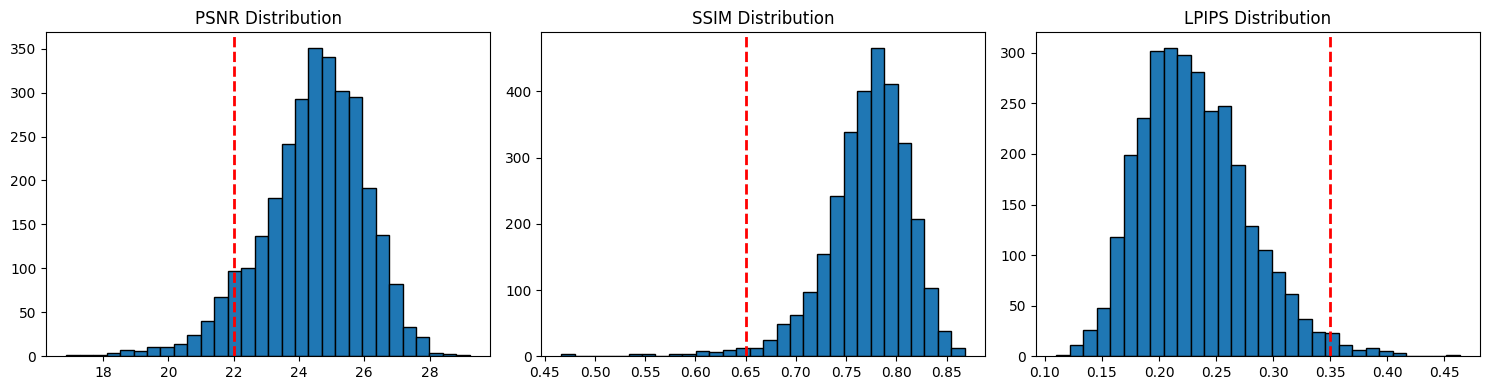

In [ ]:
# ======================
# CELL 11: Fast Failure Detection
# ======================
print("\n Computing metrics...")
results = []

for fname, pred_path in tqdm(restored_list, desc="Metrics"):
    gt_path = os.path.join(TEST_CLEAN, fname)
    gt = np.array(Image.open(gt_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    pred = np.array(Image.open(pred_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))

    psnr_val = sk_psnr(gt, pred, data_range=255)
    ssim_val = sk_ssim(gt, pred, channel_axis=2, data_range=255)

    # LPIPS (batched for speed)
    p_t = torch.from_numpy(pred.astype(np.float32)/255.).permute(2,0,1).unsqueeze(0).to(DEVICE) * 2 - 1
    g_t = torch.from_numpy(gt.astype(np.float32)/255.).permute(2,0,1).unsqueeze(0).to(DEVICE) * 2 - 1

    with torch.no_grad():
        lpips_val = lpips_fn(g_t, p_t).item()

    is_fail = (psnr_val < PSNR_THRESH) or (ssim_val < SSIM_THRESH) or (lpips_val > LPIPS_THRESH)

    results.append({
        "filename": fname,
        "PSNR": psnr_val,
        "SSIM": ssim_val,
        "LPIPS": lpips_val,
        "Failure": int(is_fail)
    })

df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(LOG_DIR, "failure_results.csv"), index=False)
failures = df_results['Failure'].sum()
print(f"Failures: {failures}/{len(df_results)} ({100*failures/len(df_results):.1f}%)")

# Quick visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_results['PSNR'], bins=30, edgecolor='black')
axes[0].axvline(PSNR_THRESH, color='r', linestyle='--', linewidth=2)
axes[0].set_title('PSNR Distribution')
axes[1].hist(df_results['SSIM'], bins=30, edgecolor='black')
axes[1].axvline(SSIM_THRESH, color='r', linestyle='--', linewidth=2)
axes[1].set_title('SSIM Distribution')
axes[2].hist(df_results['LPIPS'], bins=30, edgecolor='black')
axes[2].axvline(LPIPS_THRESH, color='r', linestyle='--', linewidth=2)
axes[2].set_title('LPIPS Distribution')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'metrics_dist.png'), dpi=150)
plt.show()

In [ ]:
# ======================
# CELL 12: FAISS Index (Optimized)
# ======================
print("\n Building FAISS index...")
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(DEVICE).eval()
feature_model = torch.nn.Sequential(*list(resnet.children())[:-1])

def extract_features_batch(image_paths, batch_size=32):
    """Extract features in batches"""
    features = []
    transform = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = []
        for path in batch_paths:
            img = Image.open(path).convert('RGB')
            batch.append(transform(img))

        batch = torch.stack(batch).to(DEVICE)
        with torch.no_grad():
            if use_amp:
                with autocast():
                    feats = feature_model(batch).squeeze().cpu().numpy()
            else:
                feats = feature_model(batch).squeeze().cpu().numpy()

        if feats.ndim == 1:
            feats = feats.reshape(1, -1)
        features.append(feats)

        if i % 200 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.vstack(features).astype('float32')

# Get training files
train_files = sorted([p.name for p in Path(TRAIN_CLEAN).iterdir()
                     if p.suffix.lower() in ('.jpg', '.png', '.jpeg')])
train_paths = [os.path.join(TRAIN_CLEAN, f) for f in train_files]

feat_cache = os.path.join(LOG_DIR, "train_feats.npy")
if os.path.exists(feat_cache):
    print(" Loading cached features...")
    train_feats = np.load(feat_cache)
else:
    train_feats = extract_features_batch(train_paths, batch_size=32)
    np.save(feat_cache, train_feats)

with open(os.path.join(LOG_DIR, "train_files.txt"), 'w') as f:
    f.write('\n'.join(train_files))

# Build FAISS
index = faiss.IndexFlatL2(train_feats.shape[1])
index.add(train_feats)
print(f"FAISS index: {index.ntotal} vectors")


 Building FAISS index...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


 Loading cached features...
FAISS index: 24000 vectors


In [ ]:
# ======================
# CELL 13: NN Retrieval
# ======================
print("\n Finding nearest neighbors for failures.")
failed_rows = df_results[df_results['Failure'] == 1]
print(f"  Processing {len(failed_rows)} failed images.")

nn_records = []
for _, row in tqdm(failed_rows.iterrows(), total=len(failed_rows), desc="NN search"):
    fname = row['filename']
    pred_path = os.path.join(OUTPUT_DIR, fname)

    # Extract feature
    img = Image.open(pred_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_t = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feat = feature_model(img_t).squeeze().cpu().numpy().reshape(1, -1).astype('float32')

    D, I = index.search(feat, k=NN_K)
    neighbors = [train_files[i] for i in I[0]]
    distances = D[0].tolist()

    nn_records.append({
        'filename': fname,
        'NN_files': neighbors,
        'NN_distances': distances,
        'PSNR': row['PSNR'],
        'SSIM': row['SSIM'],
        'LPIPS': row['LPIPS']
    })

df_nn = pd.DataFrame(nn_records)
df_nn.to_csv(os.path.join(LOG_DIR, 'failure_with_nn.csv'), index=False)
print(f"Saved NN results")


 Finding nearest neighbors for failures.
  Processing 309 failed images.


NN search:   0%|          | 0/309 [00:00<?, ?it/s]

Saved NN results


In [ ]:
# ======================
# CELL 14: Visualization
# ======================
def visualize_failure(idx):
    if idx >= len(df_nn):
        print(f"Index out of range. Max: {len(df_nn)-1}")
        return

    row = df_nn.iloc[idx]
    fname = row['filename']

    fig, axes = plt.subplots(1, NN_K+3, figsize=(4*(NN_K+3), 4))

    # Degraded
    deg = Image.open(os.path.join(TEST_DEG, fname)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[0].imshow(deg)
    axes[0].set_title('Degraded')
    axes[0].axis('off')

    # Restored
    pred = Image.open(os.path.join(OUTPUT_DIR, fname)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[1].imshow(pred)
    axes[1].set_title('Restored')
    axes[1].axis('off')

    # GT
    gt = Image.open(os.path.join(TEST_CLEAN, fname)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[2].imshow(gt)
    axes[2].set_title('Ground Truth')
    axes[2].axis('off')

    # NNs
    neighbors = eval(row['NN_files']) if isinstance(row['NN_files'], str) else row['NN_files']
    for i, nn in enumerate(neighbors):
        nn_img = Image.open(os.path.join(TRAIN_CLEAN, nn)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        axes[i+3].imshow(nn_img)
        axes[i+3].set_title(f'NN {i+1}')
        axes[i+3].axis('off')

    plt.suptitle(f"{fname} | PSNR:{row['PSNR']:.1f} SSIM:{row['SSIM']:.2f} LPIPS:{row['LPIPS']:.3f}")
    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, f'failure_viz_{idx}.png'), dpi=150, bbox_inches='tight')
    plt.show()

if len(df_nn) > 0:
    print(f"\n Visualizing {min(3, len(df_nn))} failure cases:")
    for i in range(min(3, len(df_nn))):
        visualize_failure(i)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ======================
# FINAL SUMMARY
# ======================
print(f"Restored images: {OUTPUT_DIR}")
print(f"Metrics: {os.path.join(LOG_DIR, 'failure_results.csv')}")
print(f"NN analysis: {os.path.join(LOG_DIR, 'failure_with_nn.csv')}")
print(f"Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pth')}")
print(f"\n Results:")
print(f"Total test images: {len(df_results)}")
print(f"Failures: {df_results['Failure'].sum()} ({100*df_results['Failure'].sum()/len(df_results):.1f}%)")
print(f"Avg PSNR: {df_results['PSNR'].mean():.2f}")
print(f"Avg SSIM: {df_results['SSIM'].mean():.3f}")
print(f"Avg LPIPS: {df_results['LPIPS'].mean():.4f}")


Restored images: /content/drive/MyDrive/esrgan_experiment/restored_test
Metrics: /content/drive/MyDrive/esrgan_experiment/logs/failure_results.csv
NN analysis: /content/drive/MyDrive/esrgan_experiment/logs/failure_with_nn.csv
Best model: /content/drive/MyDrive/esrgan_experiment/checkpoints/best_model.pth

 Results:
Total test images: 3000
Failures: 309 (10.3%)
Avg PSNR: 24.44
Avg SSIM: 0.771
Avg LPIPS: 0.2312


In [ ]:
# ======================
# CELL 15: Computational Cost Analysis
# ======================
print("\n⚙️ COMPUTATIONAL COST ANALYSIS")
print("="*80)

# Measure inference time
print("Measuring inference speed...")

dummy_input = torch.randn(1, 3, 128, 128).to(DEVICE)
num_runs = 100

# Warmup
for _ in range(10):
    _ = generator(dummy_input)

# Single pass inference time
torch.cuda.synchronize() if torch.cuda.is_available() else None
start = time.time()
for _ in range(num_runs):
    _ = generator(dummy_input)
torch.cuda.synchronize() if torch.cuda.is_available() else None
time_stage1 = (time.time() - start) / num_runs

print("\nInference Time:")
print(f"  Single Pass: {time_stage1*1000:.2f} ms ({1/time_stage1:.2f} FPS)")

# Note: The original prompt included a "3-Stage" analysis, but the current notebook
# does not implement a 3-stage restoration process. We will only measure the single
# pass inference time based on the current model.

print("\n" + "="*80)
print("PERFORMANCE vs COST TRADE-OFF:")
print("="*80)

# Since we only have single-stage results, we can't directly compare performance vs cost
# in the way the original prompt suggested (comparing 1-stage vs 3-stage).
# We can, however, report the average performance metrics from the single-stage inference.

print(f"Average PSNR: {df_results['PSNR'].mean():.2f} dB")
print(f"Average SSIM: {df_results['SSIM'].mean():.3f}")
print(f"Average LPIPS: {df_results['LPIPS'].mean():.4f}")

print("\nAnalysis based on single-pass inference:")
print("The reported metrics (PSNR, SSIM, LPIPS) are for the single-pass restoration.")
print(f"The average inference time per image is {time_stage1*1000:.2f} ms.")
print("To perform a performance vs cost trade-off analysis as originally intended,")
print("a multi-stage restoration process would need to be implemented and evaluated.")